In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
help(a.format())

NameError: name 'a' is not defined

In [2]:
#Define the function
def RKF(t1, theta_0, v_0,h0, tol):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = [0]
    # n is the number of timesteps in t
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = []
    #same for velocities
    v = []
    # same for energies
    e = []
    
    #Set the initial value of x and v
    
    g = 9.81
    l = 1
    
    a21 = 1/5
    a31 = 3/40
    a32 = 9/40
    a41 = 44/45
    a42 = -56/15
    a43 = 32/9
    a51 = 19372/6561
    a52 = -25360/2187
    a53 = 64448/6561
    a54 = -212/729
    a61 = 9017/3168
    a62 = -355/33
    a63 = 46732/5247
    a64 = 49/176
    a65 = -5103/18656
    
    b1 = 35/384
    b2 = 0
    b3 = 500/1113
    b4 = 125/192
    b5 = -2187/6784
    b6 = 11/84
    
    bx1 = 5179/57600
    bx2 = 0
    bx3 = 7571/16695
    bx4 = 393/640
    bx5 = -92097/339200
    bx6 = 187/2100
    bx7 = 1/40
    
    #define F(theta) for coupled equation 1
    def F(v):
        
        return v
    
    #Define G(v) for coupled equation 2
    def G(theta):
        
        return -g/l * np.sin(theta)
    
    h = h0
    thet = theta_0
    # since i removed ve from the loop, i define it here to avoid a locality error with v_star in the loop
    ve = v_0
    E = 0.5 * v_0**2 + g*l*(1-np.cos(theta_0))

    #Loop over the time values and calculate the derivatives
    while t[-1] < t1:
             
        t.append(t[-1]+h)
        theta.append(thet)
        v.append(ve)
        
        e.append(E)
        
        err = 2
        
        theta_star = thet
        v_star = ve
        
        while err > 1:
        
            # Calculate the Runge - Kutta intermediate values
            f1 = h * F(v[-1])
            f2 = h * F(v[-1]+a21*f1)
            f3 = h * F(v[-1]+a31*f1+a32*f2)
            f4 = h * F(v[-1]+a41*f1+a42*f2+a43*f3)
            f5 = h * F(v[-1]+a51*f1+a52*f2+a53*f3+a54*f4)
            f6 = h * F(v[-1]+a61*f1+a62*f2+a63*f3+a64*f4+a65*f5)
            f7 = h * F(v[-1]+b1*f1+b2*f2+b3*f3+b4*f4+b5*f5+b6*f6)
            
            g1 = h * G(theta[-1])
            g2 = h * G(theta[-1]+a21*g1)
            g3 = h * G(theta[-1]+a31*g1+a32*g2)
            g4 = h * G(theta[-1]+a41*g1+a42*g2+a43*g3)
            g5 = h * G(theta[-1]+a51*g1+a52*g2+a53*g3+a54*g4)
            g6 = h * G(theta[-1]+a61*g1+a62*g2+a63*g3+a64*g4+a65*g5)
            g7 = h * G(theta[-1]+b1*g1+b2*g2+b3*g3+b4*g4+b5*g5+b6*g6)
            
            
            delta1 = theta_star - thet
            delta2 = v_star - ve
            
            scale1 = tol + np.abs(np.max((thet,theta_star)))*tol
            scale2 = tol + np.abs(np.max((ve,v_star)))*tol
            
            err = np.sqrt(0.5*(delta1/scale1)**2 + 0.5*(delta2/scale2)**2)
            
            p = 0.9 * h * np.abs(1/err)**0.2
            
            if p < 10 * h and p > 5 * h:
            
                h = p
            
            # Thet and ve values are now updated after adjusting the step size and checking the error condition
            
            thet = theta[-1] + b1*f1 + b2*f2 + b3*f3 + b4*f4 + b5*f5 + b6*f6
            theta_star = theta[-1] + bx1*f1 + bx2*f2 + bx3*f3 + bx4*f4 + bx5*f5 + bx6*f6 + bx7*f7
            
            ve = v[-1] + b1*g1 + b2*g2 + b3*g3 + b4*g4 + b5*g5 + b6*g6
            v_star = v[-1] + bx1*g1 + bx2*g2 + bx3*g3 + bx4*g4 + bx5*g5 + bx6*g6 + bx7*g7   
            E = 0.5 * ve**2 + g*l*(1-np.cos(thet))
            
            print("t = {0} : err = {1} : h = {2}".format(t[-1],err,h))
        
        
        
        
    return(t,theta,v,e) 

/tmp/ipykernel_2477530/2707780588.py:109: RuntimeWarning: divide by zero encountered in scalar divide
  p = 0.9 * h * np.abs(1/err)**0.2


t = 0.01 : err = 0.0 : h = 0.01
t = 0.02 : err = 0.0 : h = 0.01
t = 0.03 : err = 0.0 : h = 0.01
t = 0.04 : err = 0.0 : h = 0.01
t = 0.05 : err = 0.0 : h = 0.01
t = 0.060000000000000005 : err = 0.0 : h = 0.01
t = 0.07 : err = 0.0 : h = 0.01
t = 0.08 : err = 0.0 : h = 0.01
t = 0.09 : err = 0.0 : h = 0.01
t = 0.09999999999999999 : err = 0.0 : h = 0.01
t = 0.10999999999999999 : err = 0.0 : h = 0.01
t = 0.11999999999999998 : err = 0.0 : h = 0.01
t = 0.12999999999999998 : err = 0.0 : h = 0.01
t = 0.13999999999999999 : err = 0.0 : h = 0.01
t = 0.15 : err = 0.0 : h = 0.01
t = 0.16 : err = 0.0 : h = 0.01
t = 0.17 : err = 0.0 : h = 0.01
t = 0.18000000000000002 : err = 0.0 : h = 0.01
t = 0.19000000000000003 : err = 0.0 : h = 0.01
t = 0.20000000000000004 : err = 0.0 : h = 0.01
t = 0.21000000000000005 : err = 0.0 : h = 0.01
t = 0.22000000000000006 : err = 0.0 : h = 0.01
t = 0.23000000000000007 : err = 0.0 : h = 0.01
t = 0.24000000000000007 : err = 0.0 : h = 0.01
t = 0.25000000000000006 : err = 0.0 

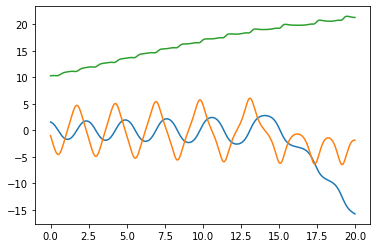

In [3]:
t,theta,v, e = RKF(20,np.pi/2,-1,0.01,0.000001)

plt.plot(t[0:-1],theta)
plt.plot(t[0:-1],v)
plt.plot(t[0:-1], e)